<a href="https://colab.research.google.com/github/nykollg/TRABAJO-GRADO/blob/main/CondicionesdeVidaHogar.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **ANÁLISIS DISCRIMINANTE CUADRÁTICO**

In [ ]:
from google.colab import files # Para cargar archivos en google colab
uploaded = files.upload()

In [ ]:
import pandas as pd
import io
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import precision_score

In [ ]:
datos_calidad = pd.read_csv(io.BytesIO(uploaded['DBF_ENCV_591_3.CSV']), delimiter=';')
tabla_calidad = datos_calidad[['P9090', 'P1077S2', 'P1075', 'P3353', 'P3516S1']]
tabla_calidad1 = tabla_calidad[tabla_calidad.P1077S2.notnull()]
tabla_calidad1.head(4)


,P9090,P1077S2,P1075,P3353,P3516S1
0,1,1,1,2,1
1,1,1,1,4,1
2,1,1,1,3,2
3,1,1,2,4,2


In [ ]:
dummi_calidad = pd.get_dummies(tabla_calidad1, columns=[ "P1077S2", "P1075", "P3353", "P3516S1"], dtype = float)
dummi_calidad.head(5)



,P9090,P1077S2_1,P1077S2_2,P1075_1,P1075_2,P3353_1,P3353_2,P3353_3,P3353_4,P3353_5,P3516S1_1,P3516S1_2,P3516S1_3
0,1,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
1,1,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
2,1,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
3,1,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
4,1,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0


In [ ]:
dummi_calidad.rename(columns = {'P1077S2_1':'Tiene nev', 'P1077S2_2':'no tiene nev'}, inplace = True)
dummi_calidad.rename(columns = {'P1075_1':"Tiene internet", 'P1075_2':"No tiene internet"}, inplace = True)
dummi_calidad.rename(columns = {'P3353_1':"Mucho mejor", 'P3353_2':"Mejor", 'P3353_3':"Igual", 'P3353_4':"Peor", 'P3353_5':"Mucho peor"}, inplace = True)
dummi_calidad.rename(columns = {'P3516S1_1':"sí se preocupó", 'P3516S1_2':"no se preocupó", 'P3516S1_3':"no sabe/responde"}, inplace = True)
dummi_calidad.head(5)

,P9090,Tiene nev,no tiene nev,Tiene internet,No tiene internet,Mucho mejor,Mejor,Igual,Peor,Mucho peor,sí se preocupó,no se preocupó,no sabe/responde
0,1,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
1,1,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
2,1,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
3,1,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
4,1,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0


In [ ]:
x = dummi_calidad.drop(["P9090", 'P9090'], axis = 1)
y = dummi_calidad["P9090"].astype(str)
y.loc[(y == "1")] = "No alcanza"
y.loc[(y == "2")] = "Solo alcanza"
y.loc[(y == "3")] = "Cubre más"
y.value_counts()

,count
P9090,
No alcanza,44988
Solo alcanza,39758
Cubre más,3582


/usr/local/lib/python3.10/dist-packages/sklearn/discriminant_analysis.py:947: UserWarning: Variables are collinear
  warnings.warn("Variables are collinear")


Exactitud del modelo: 0.51
Precisión para cada clase:
Clase Cubre más: 0.13
Clase No alcanza: 0.61
Clase Solo alcanza: 0.62

Precisión promedio (macro): 0.46


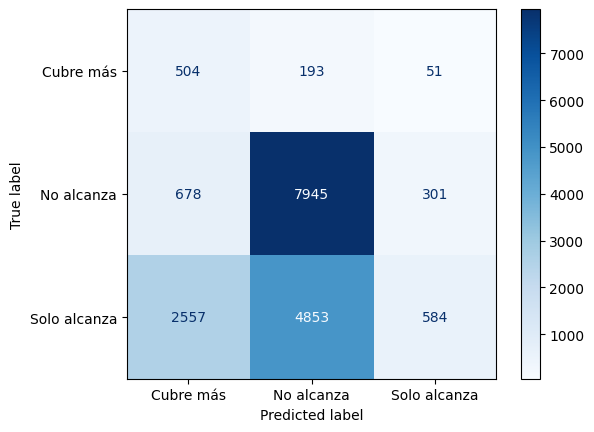

In [ ]:

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
model = QuadraticDiscriminantAnalysis()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
disp.plot(cmap='Blues')


accuracy = accuracy_score(y_test, y_pred)
print(f"Exactitud del modelo: {accuracy:.2f}")
# Calcular la precisión para cada clase
precision = precision_score(y_test, y_pred, average=None)  # average=None devuelve la precisión para cada clase

# Calcular la precisión promedio (macro)
precision_macro = precision_score(y_test, y_pred, average='macro')

# Imprimir la precisión
print("Precisión para cada clase:")
for i, prec in enumerate(precision):
    print(f"Clase {label_encoder.classes_[i]}: {prec:.2f}")

print(f"\nPrecisión promedio (macro): {precision_macro:.2f}")

# **MÁQUINA DE SOPORTE VECTORIAL**

In [ ]:
from sklearn.svm import SVC
soporte_vect = SVC(decision_function_shape='ovr', kernel = "rbf", degree = 3)
soporte_vect.fit(X_train, y_train)
y_pred_sopor = soporte_vect.predict(X_test)
print('Accuracy: {:.2f}'.format(accuracy_score(y_pred_sopor, y_test)))

Accuracy: 0.67


Exactitud del modelo: 0.51
Precisión para cada clase:
Clase Cubre más: 0.13
Clase No alcanza: 0.61
Clase Solo alcanza: 0.62

Precisión promedio (macro): 0.46


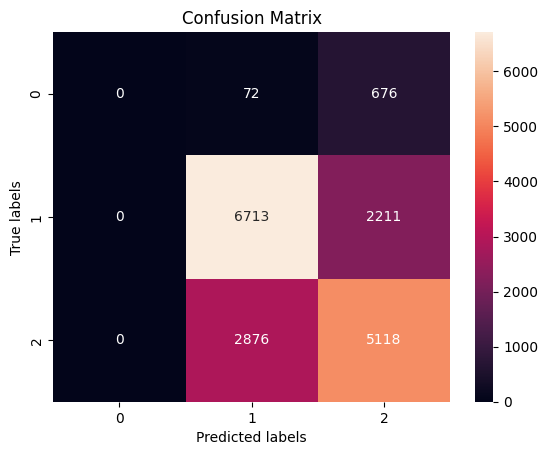

In [ ]:
from sklearn.metrics import confusion_matrix
import pylab as pl
cm2 = confusion_matrix(y_test, y_pred_sopor)
cm2
import seaborn as sns
import matplotlib.pyplot as plt
ax= plt.subplot()
sns.heatmap(cm2, annot=True, fmt='g', ax=ax);
ax.set_xlabel('Predicted labels');ax.set_ylabel('True labels');
ax.set_title('Confusion Matrix')


accuracy = accuracy_score(y_test, y_pred)
print(f"Exactitud del modelo: {accuracy:.2f}")
# Calcular la precisión para cada clase
precision = precision_score(y_test, y_pred, average=None)  # average=None devuelve la precisión para cada clase

# Calcular la precisión promedio (macro)
precision_macro = precision_score(y_test, y_pred, average='macro')

# Imprimir la precisión
print("Precisión para cada clase:")
for i, prec in enumerate(precision):
    print(f"Clase {label_encoder.classes_[i]}: {prec:.2f}")

print(f"\nPrecisión promedio (macro): {precision_macro:.2f}")

# **CLASIFICACIÓN GAUSSIANA**

Matriz de Confusión:
[[ 504   62  182]
 [ 678 6051 2195]
 [2557 2421 3016]]
Exactitud del modelo: 0.54
Precisión para cada clase:
Clase Cubre más: 0.13
Clase No alcanza: 0.71
Clase Solo alcanza: 0.56

Precisión promedio (macro): 0.47


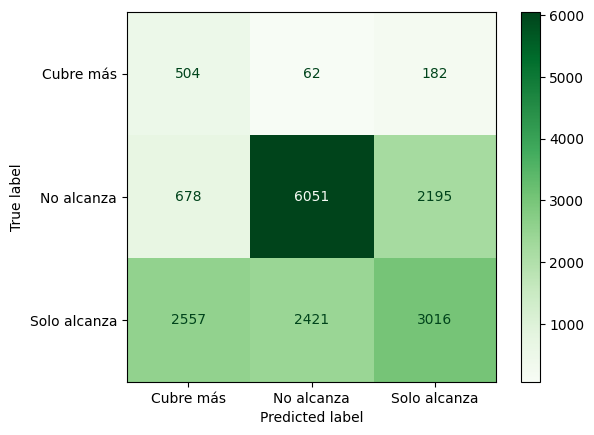

In [ ]:

from sklearn.naive_bayes import GaussianNB

model = GaussianNB()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

print("Matriz de Confusión:")
print(cm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
disp.plot(cmap='Greens')


accuracy = accuracy_score(y_test, y_pred)
print(f"Exactitud del modelo: {accuracy:.2f}")
# Calcular la precisión para cada clase
precision = precision_score(y_test, y_pred, average=None)  # average=None devuelve la precisión para cada clase

# Calcular la precisión promedio (macro)
precision_macro = precision_score(y_test, y_pred, average='macro')

# Imprimir la precisión
print("Precisión para cada clase:")
for i, prec in enumerate(precision):
    print(f"Clase {label_encoder.classes_[i]}: {prec:.2f}")

print(f"\nPrecisión promedio (macro): {precision_macro:.2f}")

# **ARBOLES DE DECISIÓN**

Matriz de Confusión:
[[   0   74  674]
 [   0 6717 2207]
 [   0 2878 5116]]
Exactitud del modelo: 0.67
Precisión para cada clase:
Clase Cubre más: 0.00
Clase No alcanza: 0.69
Clase Solo alcanza: 0.64

Precisión promedio (macro): 0.44


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


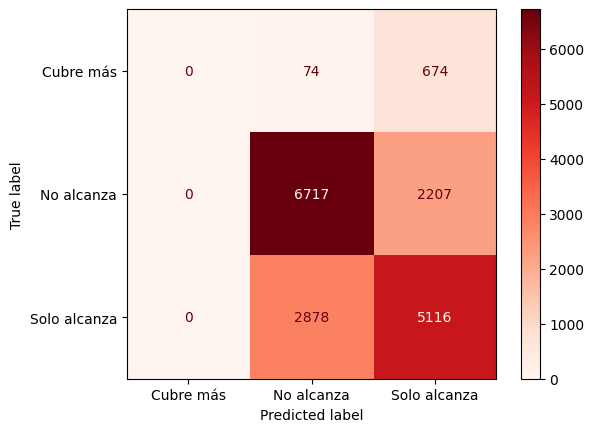

In [ ]:
from sklearn.ensemble import RandomForestClassifier
random_forest = RandomForestClassifier(n_estimators=100, random_state=42)

model = random_forest
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

print("Matriz de Confusión:")
print(cm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
disp.plot(cmap='Reds')


accuracy = accuracy_score(y_test, y_pred)
print(f"Exactitud del modelo: {accuracy:.2f}")
# Calcular la precisión para cada clase
precision = precision_score(y_test, y_pred, average=None)  # average=None devuelve la precisión para cada clase

# Calcular la precisión promedio (macro)
precision_macro = precision_score(y_test, y_pred, average='macro')

# Imprimir la precisión
print("Precisión para cada clase:")
for i, prec in enumerate(precision):
    print(f"Clase {label_encoder.classes_[i]}: {prec:.2f}")

print(f"\nPrecisión promedio (macro): {precision_macro:.2f}")

Exactitud del modelo: 0.67
Precisión para cada clase:
Clase Cubre más: 0.00
Clase No alcanza: 0.69
Clase Solo alcanza: 0.64

Precisión promedio (macro): 0.44


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


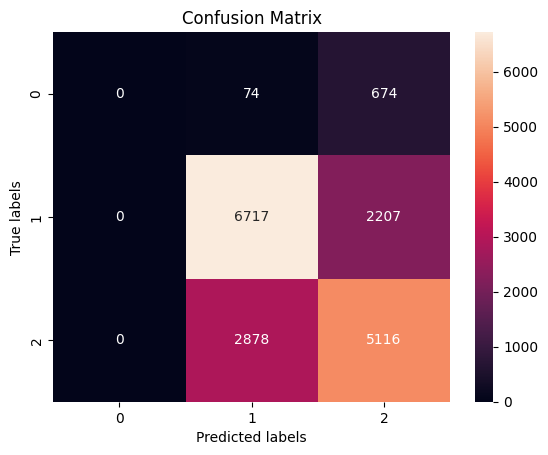

In [ ]:

from sklearn.ensemble import RandomForestClassifier
random_forest = RandomForestClassifier(n_estimators=100, random_state=42)
random_forest.fit(X_train, y_train)
y_pred_random = random_forest.predict(X_test)

from sklearn.metrics import confusion_matrix
import pylab as pl
cm1 = confusion_matrix(y_test, y_pred_random)
cm1
import seaborn as sns
import matplotlib.pyplot as plt
ax= plt.subplot()
sns.heatmap(cm1, annot=True, fmt='g', ax=ax);  #annot=True to annotate cells, ftm='g' to disable scientific notation
# labels, title and ticks
ax.set_xlabel('Predicted labels');ax.set_ylabel('True labels');
ax.set_title('Confusion Matrix')



accuracy = accuracy_score(y_test, y_pred)
print(f"Exactitud del modelo: {accuracy:.2f}")
# Calcular la precisión para cada clase
precision = precision_score(y_test, y_pred, average=None)  # average=None devuelve la precisión para cada clase

# Calcular la precisión promedio (macro)
precision_macro = precision_score(y_test, y_pred, average='macro')

# Imprimir la precisión
print("Precisión para cada clase:")
for i, prec in enumerate(precision):
    print(f"Clase {label_encoder.classes_[i]}: {prec:.2f}")

print(f"\nPrecisión promedio (macro): {precision_macro:.2f}")

**CLASIFICACIÓN DE VOTACIÓN**

Matriz de Confusión:
Exactitud del modelo: 0.55
Precisión para cada clase:
Clase Cubre más: 0.13
Clase No alcanza: 0.69
Clase Solo alcanza: 0.60

Precisión promedio (macro): 0.48


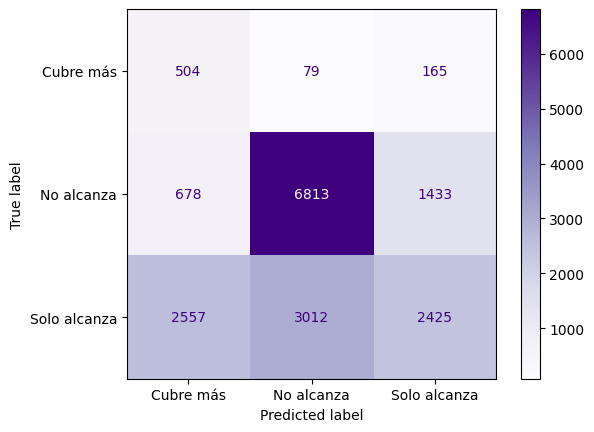

In [ ]:
from sklearn.ensemble import VotingClassifier
model1 = GaussianNB()
model2 = RandomForestClassifier(random_state=42)

voting_model = VotingClassifier(
    estimators=[('gnb', model1), ('rf', model2)],
    voting='hard'  )

voting_model.fit(X_train, y_train)


y_pred = voting_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)


print("Matriz de Confusión:")
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
disp.plot(cmap='Purples')


accuracy = accuracy_score(y_test, y_pred)
print(f"Exactitud del modelo: {accuracy:.2f}")
# Calcular la precisión para cada clase
precision = precision_score(y_test, y_pred, average=None)  # average=None devuelve la precisión para cada clase

# Calcular la precisión promedio (macro)
precision_macro = precision_score(y_test, y_pred, average='macro')

# Imprimir la precisión
print("Precisión para cada clase:")
for i, prec in enumerate(precision):
    print(f"Clase {label_encoder.classes_[i]}: {prec:.2f}")

print(f"\nPrecisión promedio (macro): {precision_macro:.2f}")

Matriz de Confusión:
Exactitud del modelo: 0.63
Precisión para cada clase:
Clase Cubre más: 0.22
Clase No alcanza: 0.71
Clase Solo alcanza: 0.61

Precisión promedio (macro): 0.51


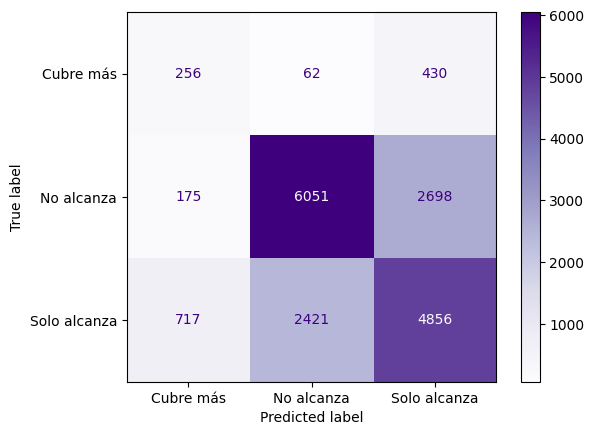

In [ ]:
model3 = GaussianNB()
model4 = RandomForestClassifier(random_state=42)

voting_model = VotingClassifier(
    estimators=[('gnb', model3), ('rf', model4)],
    voting='soft'  )

voting_model.fit(X_train, y_train)


y_pred = voting_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)


print("Matriz de Confusión:")
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
disp.plot(cmap='Purples')



accuracy = accuracy_score(y_test, y_pred)
print(f"Exactitud del modelo: {accuracy:.2f}")
# Calcular la precisión para cada clase
precision = precision_score(y_test, y_pred, average=None)  # average=None devuelve la precisión para cada clase

# Calcular la precisión promedio (macro)
precision_macro = precision_score(y_test, y_pred, average='macro')

# Imprimir la precisión
print("Precisión para cada clase:")
for i, prec in enumerate(precision):
    print(f"Clase {label_encoder.classes_[i]}: {prec:.2f}")

print(f"\nPrecisión promedio (macro): {precision_macro:.2f}")

# **RIDGE DE CLASIFICACIÓN**

Exactitud del modelo: 0.67
Precisión para cada clase:
Clase Cubre más: 0.00
Clase No alcanza: 0.69
Clase Solo alcanza: 0.64

Precisión promedio (macro): 0.44


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


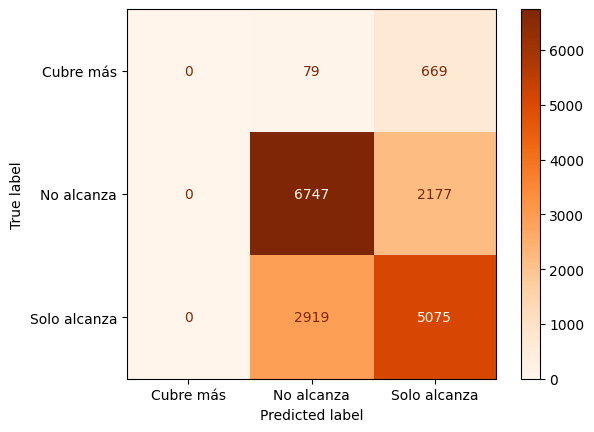

In [ ]:
from sklearn.linear_model import RidgeClassifier
model = RidgeClassifier()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
disp.plot(cmap='Oranges')


accuracy = accuracy_score(y_test, y_pred)
print(f"Exactitud del modelo: {accuracy:.2f}")
# Calcular la precisión para cada clase
precision = precision_score(y_test, y_pred, average=None)  # average=None devuelve la precisión para cada clase

# Calcular la precisión promedio (macro)
precision_macro = precision_score(y_test, y_pred, average='macro')

# Imprimir la precisión
print("Precisión para cada clase:")
for i, prec in enumerate(precision):
    print(f"Clase {label_encoder.classes_[i]}: {prec:.2f}")

print(f"\nPrecisión promedio (macro): {precision_macro:.2f}")

# **ANÁLISIS DISCRIMINANTE LINEAL**

Exactitud del modelo: 0.67
Precisión para cada clase:
Clase Cubre más: 0.27
Clase No alcanza: 0.69
Clase Solo alcanza: 0.64

Precisión promedio (macro): 0.54


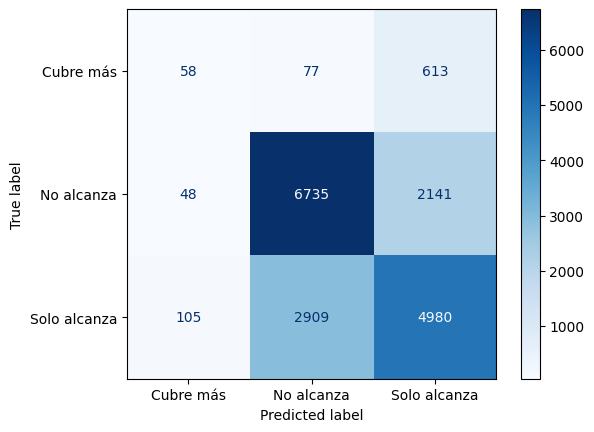

In [ ]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
model = LinearDiscriminantAnalysis()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
disp.plot(cmap='Blues')

accuracy = accuracy_score(y_test, y_pred)
print(f"Exactitud del modelo: {accuracy:.2f}")
# Calcular la precisión para cada clase
precision = precision_score(y_test, y_pred, average=None)  # average=None devuelve la precisión para cada clase

# Calcular la precisión promedio (macro)
precision_macro = precision_score(y_test, y_pred, average='macro')

# Imprimir la precisión
print("Precisión para cada clase:")
for i, prec in enumerate(precision):
    print(f"Clase {label_encoder.classes_[i]}: {prec:.2f}")

print(f"\nPrecisión promedio (macro): {precision_macro:.2f}")

# **VECINOS MÁS CERCANOS**

Exactitud del modelo: 0.57
Precisión para cada clase:
Clase Cubre más: 0.21
Clase No alcanza: 0.64
Clase Solo alcanza: 0.54

Precisión promedio (macro): 0.46


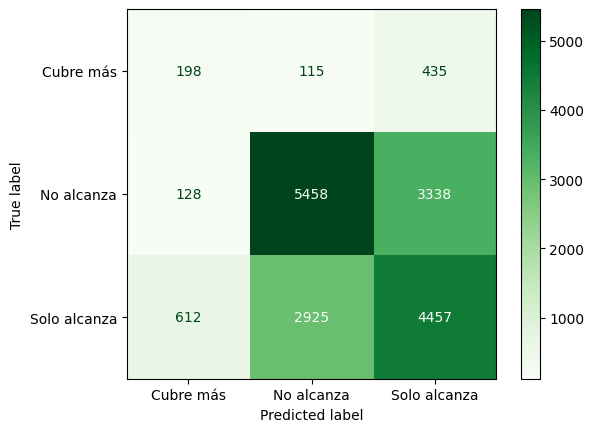

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
disp.plot(cmap='Greens')

accuracy = accuracy_score(y_test, y_pred)
print(f"Exactitud del modelo: {accuracy:.2f}")
# Calcular la precisión para cada clase
precision = precision_score(y_test, y_pred, average=None)  # average=None devuelve la precisión para cada clase

# Calcular la precisión promedio (macro)
precision_macro = precision_score(y_test, y_pred, average='macro')

# Imprimir la precisión
print("Precisión para cada clase:")
for i, prec in enumerate(precision):
    print(f"Clase {label_encoder.classes_[i]}: {prec:.2f}")

print(f"\nPrecisión promedio (macro): {precision_macro:.2f}")


# **CLASIFICACIÓN BAYEN NAIVE**

Exactitud del modelo: 0.54
Precisión para cada clase:
Clase Cubre más: 0.13
Clase No alcanza: 0.71
Clase Solo alcanza: 0.56

Precisión promedio (macro): 0.47


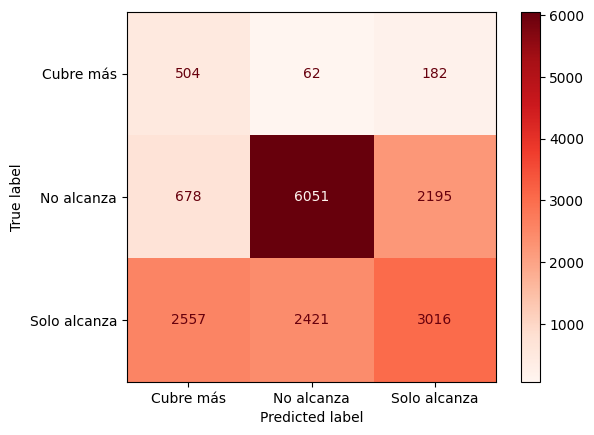

In [ ]:
from sklearn.naive_bayes import GaussianNB
model = GaussianNB()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
disp.plot(cmap='Reds')


accuracy = accuracy_score(y_test, y_pred)
print(f"Exactitud del modelo: {accuracy:.2f}")
# Calcular la precisión para cada clase
precision = precision_score(y_test, y_pred, average=None)  # average=None devuelve la precisión para cada clase

# Calcular la precisión promedio (macro)
precision_macro = precision_score(y_test, y_pred, average='macro')

# Imprimir la precisión
print("Precisión para cada clase:")
for i, prec in enumerate(precision):
    print(f"Clase {label_encoder.classes_[i]}: {prec:.2f}")

print(f"\nPrecisión promedio (macro): {precision_macro:.2f}")

# **GRADIENTE BOOSTED ARBOLES**

Exactitud del modelo: 0.67
Precisión para cada clase:
Clase Cubre más: 0.00
Clase No alcanza: 0.69
Clase Solo alcanza: 0.64

Precisión promedio (macro): 0.44


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


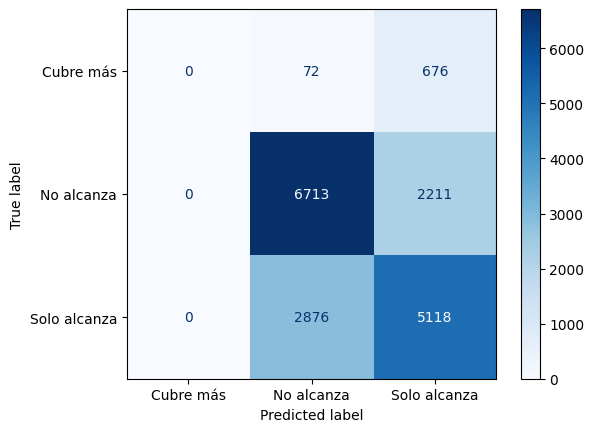

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
model = GradientBoostingClassifier()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
disp.plot(cmap='Blues')


accuracy = accuracy_score(y_test, y_pred)
print(f"Exactitud del modelo: {accuracy:.2f}")
# Calcular la precisión para cada clase
precision = precision_score(y_test, y_pred, average=None)  # average=None devuelve la precisión para cada clase

# Calcular la precisión promedio (macro)
precision_macro = precision_score(y_test, y_pred, average='macro')

# Imprimir la precisión
print("Precisión para cada clase:")
for i, prec in enumerate(precision):
    print(f"Clase {label_encoder.classes_[i]}: {prec:.2f}")

print(f"\nPrecisión promedio (macro): {precision_macro:.2f}")

# **REDES PARA CLASIFICACIÓN**

Exactitud del modelo: 0.67
Precisión para cada clase:
Clase Cubre más: 0.00
Clase No alcanza: 0.69
Clase Solo alcanza: 0.64

Precisión promedio (macro): 0.44


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


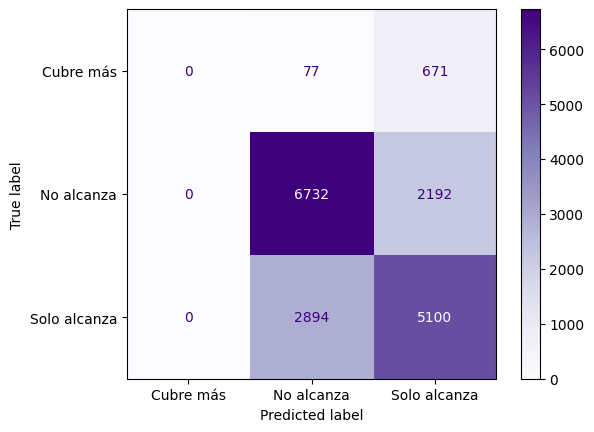

In [ ]:
from sklearn.neural_network import MLPClassifier
model = MLPClassifier(random_state=42, max_iter=500)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
disp.plot(cmap='Purples')


accuracy = accuracy_score(y_test, y_pred)
print(f"Exactitud del modelo: {accuracy:.2f}")
# Calcular la precisión para cada clase
precision = precision_score(y_test, y_pred, average=None)  # average=None devuelve la precisión para cada clase

# Calcular la precisión promedio (macro)
precision_macro = precision_score(y_test, y_pred, average='macro')

# Imprimir la precisión
print("Precisión para cada clase:")
for i, prec in enumerate(precision):
    print(f"Clase {label_encoder.classes_[i]}: {prec:.2f}")

print(f"\nPrecisión promedio (macro): {precision_macro:.2f}")

In [ ]:
from sklearn.linear_model import LogisticRegression
models = {
    'Random Forest': RandomForestClassifier(random_state=42),
    'Gaussian Naive Bayes': GaussianNB(),
    'QuadraticDiscriminantAnalysis': QuadraticDiscriminantAnalysis(),
    'SVC': SVC(),
    'LinearDiscriminantAnalysis': LinearDiscriminantAnalysis(),
    'RidgeClassifier': RidgeClassifier(),
    'KNeighborsClassifier': KNeighborsClassifier(n_neighbors=5),
    'GradientBoostingClassifier': GradientBoostingClassifier(),
    'MLPClassifier': MLPClassifier(random_state=42, max_iter=500),
    'LogisticRegression': LogisticRegression(random_state=42),
    'VotingClassifier': VotingClassifier(
        estimators=[
            ('gnb', GaussianNB()),
            ('rf', RandomForestClassifier(random_state=42))
        ],
        voting='hard'
    ),
    'VotingClassifierSoft': VotingClassifier(
        estimators=[
            ('gnb', GaussianNB()),
            ('rf', RandomForestClassifier(random_state=42))
        ],
        voting='soft'
    )


    # Puedes agregar más modelos aquí
}

# Inicializar un diccionario para almacenar las métricas
model_metrics = {}

# Entrenar y evaluar cada modelo
for model_name, model in models.items():
    # Entrenar el modelo
    model.fit(X_train, y_train)

    # Realizar predicciones
    y_pred = model.predict(X_test)

    # Calcular exactitud y precisión
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='macro', zero_division=0)  # Evitar advertencia

    # Almacenar métricas en el diccionario
    model_metrics[model_name] = {'exactitud': accuracy, 'precisión': precision}

# Convertir a DataFrame para facilitar la comparación
metrics_df = pd.DataFrame(model_metrics).T  # Transponer para tener modelos como filas
metrics_df['promedio'] = metrics_df[['exactitud', 'precisión']].mean(axis=1)

# Encontrar el mejor modelo basado en la exactitud y precisión
mejor_modelo_exactitud = metrics_df.loc[metrics_df['exactitud'].idxmax()]

# Encontrar el mejor modelo basado en la precisión
mejor_modelo_precision = metrics_df.loc[metrics_df['precisión'].idxmax()]

# Imprimir resultados
print("Métricas de los modelos:")
print(metrics_df)

print("\nMejor modelo por exactitud:")
print(mejor_modelo_exactitud)

print("\nMejor modelo por precisión:")
print(mejor_modelo_precision)

/usr/local/lib/python3.10/dist-packages/sklearn/discriminant_analysis.py:947: UserWarning: Variables are collinear
  warnings.warn("Variables are collinear")


Métricas de los modelos:
                               exactitud  precisión  promedio
Random Forest                   0.669818   0.444811  0.557315
Gaussian Naive Bayes            0.541775   0.467695  0.504735
QuadraticDiscriminantAnalysis   0.511321   0.456768  0.484045
SVC                             0.669705   0.444735  0.557220
LinearDiscriminantAnalysis      0.666421   0.537207  0.601814
RidgeClassifier                 0.669195   0.444352  0.556774
KNeighborsClassifier            0.572456   0.464970  0.518713
GradientBoostingClassifier      0.669705   0.444735  0.557220
MLPClassifier                   0.669761   0.444756  0.557259
LogisticRegression              0.669195   0.444352  0.556774
VotingClassifier                0.551455   0.475161  0.513308
VotingClassifierSoft            0.631892   0.513420  0.572656

Mejor modelo por exactitud:
exactitud    0.669818
precisión    0.444811
promedio     0.557315
Name: Random Forest, dtype: float64

Mejor modelo por precisión:
exactitud

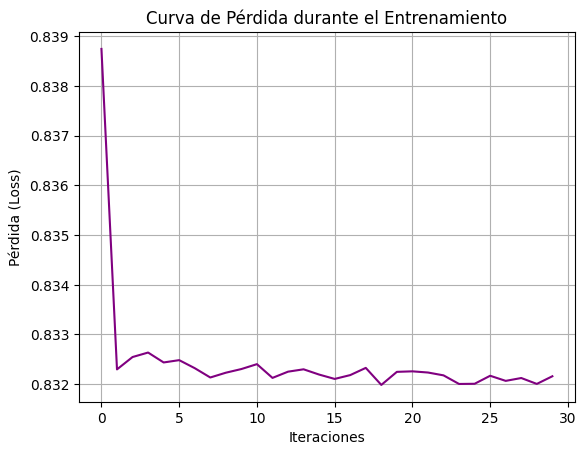

In [ ]:
mlp_clf = MLPClassifier(hidden_layer_sizes=(50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50),
                        max_iter=30, activation='logistic',
                        solver='adam', random_state=42)

mlp_clf.fit(X_train, y_train)

y_pred = mlp_clf.predict(X_test)

plt.plot(mlp_clf.loss_curve_, color='purple')
plt.title("Curva de Pérdida durante el Entrenamiento")
plt.xlabel('Iteraciones')
plt.ylabel('Pérdida (Loss)')
plt.grid(True)
plt.show()

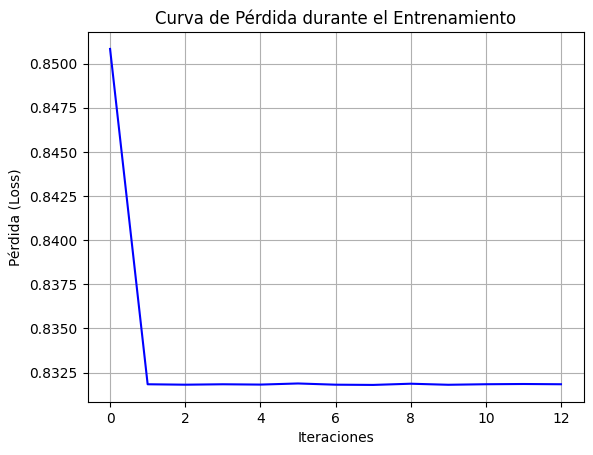

In [ ]:
mlp_clf = MLPClassifier(hidden_layer_sizes=(50, 50, 50, 50, 50, 50, 50),
                        max_iter=300, activation='logistic',
                        solver='sgd', random_state=42)

mlp_clf.fit(X_train, y_train)

y_pred = mlp_clf.predict(X_test)

plt.plot(mlp_clf.loss_curve_, color='blue')
plt.title("Curva de Pérdida durante el Entrenamiento")
plt.xlabel('Iteraciones')
plt.ylabel('Pérdida (Loss)')
plt.grid(True)
plt.show()

Text(0.5, 1.0, 'Confusion Matrix')

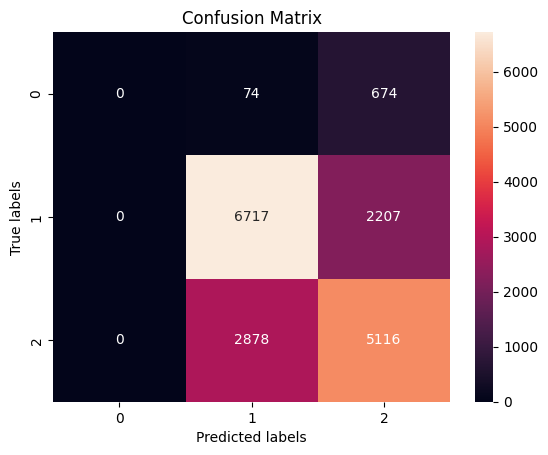

In [ ]:
from sklearn.ensemble import RandomForestClassifier
random_forest = RandomForestClassifier(n_estimators=100, random_state=42)
random_forest.fit(X_train, y_train)
y_pred_random = random_forest.predict(X_test)
import pylab as pl
cm1 = confusion_matrix(y_test, y_pred_random)
cm1
import seaborn as sns
import matplotlib.pyplot as plt
ax= plt.subplot()
sns.heatmap(cm1, annot=True, fmt='g', ax=ax);  #annot=True to annotate cells, ftm='g' to disable scientific notation
# labels, title and ticks
ax.set_xlabel('Predicted labels');ax.set_ylabel('True labels');
ax.set_title('Confusion Matrix')

In [ ]:
pip install pygam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 522.0/522.0 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.4/36.4 MB 28.8 MB/s eta 0:00:00
  Attempting uninstall: scipy
    Found existing installation: scipy 1.13.1
    Uninstalling scipy-1.13.1:
      Successfully uninstalled scipy-1.13.1


Matriz de Confusión:
[[144   7]
 [  7 142]]

Exactitud del modelo: 0.95

Precisión para cada clase:
Clase 0: 0.95
Clase 1: 0.95

Precisión promedio (macro): 0.95


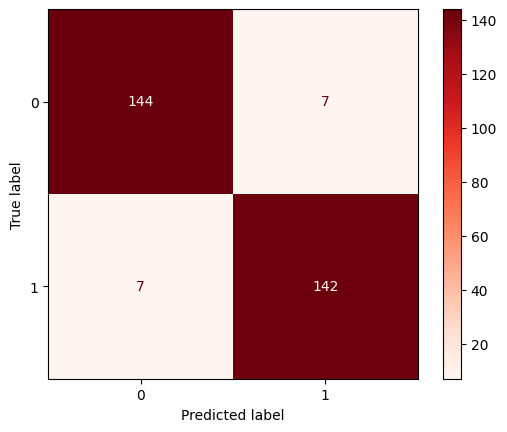

In [ ]:
import numpy as np
from pygam import LogisticGAM, s
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# Simulamos algunos datos (usa tus datos reales aquí)
from sklearn.datasets import make_classification
X, y = make_classification(n_samples=1000, n_features=5, n_informative=3, n_redundant=2, random_state=42)

# Dividimos los datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Codificar las etiquetas si es necesario
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

# Configurar y entrenar el modelo de FDA
fda = LogisticGAM(s(0) + s(1) + s(2) + s(3) + s(4))  # Ajustamos un spline por cada variable
fda.fit(X_train, y_train_encoded)

# Realizar predicciones
y_pred = fda.predict(X_test)

# Calcular y mostrar la matriz de confusión
cm = confusion_matrix(y_test_encoded, y_pred)
print("Matriz de Confusión:")
print(cm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
disp.plot(cmap='Reds')

# Calcular métricas de desempeño
accuracy = accuracy_score(y_test_encoded, y_pred)
print(f"\nExactitud del modelo: {accuracy:.2f}")

# Calcular la precisión para cada clase
precision = precision_score(y_test_encoded, y_pred, average=None)
precision_macro = precision_score(y_test_encoded, y_pred, average='macro')

# Imprimir resultados de precisión
print("\nPrecisión para cada clase:")
for i, prec in enumerate(precision):
    print(f"Clase {label_encoder.classes_[i]}: {prec:.2f}")

print(f"\nPrecisión promedio (macro): {precision_macro:.2f}")


Matriz de Confusión:
[[86  7  1]
 [ 2 96  8]
 [13  1 86]]

Exactitud del modelo: 0.89

Precisión para cada clase:
Clase 0: 0.85
Clase 1: 0.92
Clase 2: 0.91

Precisión promedio (macro): 0.89


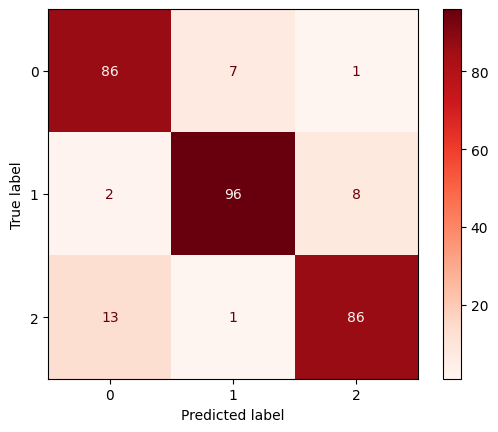

In [ ]:
import numpy as np
from pygam import LogisticGAM, s
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_classification

# Generar datos con 3 clases
X, y = make_classification(
    n_samples=1000,
    n_features=5,
    n_informative=3,
    n_redundant=2,
    n_classes=3,  # Generamos 3 clases
    n_clusters_per_class=1,
    random_state=42
)

# Dividir los datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Codificar etiquetas si es necesario
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

# Entrenar un LogisticGAM por clase (One-vs-Rest manual)
classifiers = []
for class_label in np.unique(y_train_encoded):
    # Crear etiquetas binarizadas para la clase actual
    y_train_binary = (y_train_encoded == class_label).astype(int)
    gam = LogisticGAM(s(0) + s(1) + s(2) + s(3) + s(4))
    gam.fit(X_train, y_train_binary)
    classifiers.append(gam)

# Predecir probabilidades para cada clase
probabilities = np.zeros((X_test.shape[0], len(classifiers)))
for i, gam in enumerate(classifiers):
    probabilities[:, i] = gam.predict_proba(X_test)

# Asignar la clase con la mayor probabilidad
y_pred = np.argmax(probabilities, axis=1)

# Calcular y mostrar la matriz de confusión
cm = confusion_matrix(y_test_encoded, y_pred)
print("Matriz de Confusión:")
print(cm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
disp.plot(cmap='Reds')

# Calcular métricas de desempeño
accuracy = accuracy_score(y_test_encoded, y_pred)
print(f"\nExactitud del modelo: {accuracy:.2f}")

# Calcular la precisión para cada clase
precision = precision_score(y_test_encoded, y_pred, average=None)
precision_macro = precision_score(y_test_encoded, y_pred, average='macro')

# Imprimir resultados de precisión
print("\nPrecisión para cada clase:")
for i, prec in enumerate(precision):
    print(f"Clase {label_encoder.classes_[i]}: {prec:.2f}")

print(f"\nPrecisión promedio (macro): {precision_macro:.2f}")
